In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np
import os

In [2]:
def zoomed_img(start_x = 0, start_y = 0, zoom_size = 128, show_numbers=False):
    zoomed_img = img[start_y : start_y + zoom_size, start_x : start_x + zoom_size]

    # --- 1. BULLETPROOF PIXEL MATH ---
    dpi = 300
    target_total_pixels = 2400
    
    # Force exactly an integer number of physical pixels per image cell
    pixels_per_cell = max(1, int(round(target_total_pixels / zoom_size)))
    
    # Calculate the exact figure size needed for perfect division
    exact_inches = (zoom_size * pixels_per_cell) / dpi
    
    fig = plt.figure(figsize=(exact_inches, exact_inches), dpi=dpi)
    
    # Use add_axes([left, bottom, width, height]) to force exactly 100% canvas fill. 
    # This is much stricter than subplots_adjust().
    ax = fig.add_axes([0, 0, 1, 1]) 
    # ---------------------------------
    
    ax.imshow(zoomed_img, interpolation='nearest', cmap='gray')
    
    # Lock the exact boundaries so the image isn't squished by sub-pixels
    ax.set_xlim(-0.5, zoom_size - 0.5)
    ax.set_ylim(zoom_size - 0.5, -0.5) # y is inverted in image coordinates
    
    ax.set_xticks(np.arange(-0.5, zoom_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, zoom_size, 1), minor=True)
    
    # Calculate a line width that equals EXACTLY 3 physical screen pixels.
    # Formula: points = pixels * (72 / dpi)
    exact_lw_points = 3 * (72 / dpi)
    
    ax.grid(which='minor', color='white', linestyle='-', linewidth=exact_lw_points)
    
    # Strip the default axis border (spines) to prevent 1px shifts
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    
    # Add pixel intensity numbers
    if show_numbers:
        for i in range(zoom_size):      
            for j in range(zoom_size):  
                val = zoomed_img[i, j]
                val_255 = int(val * 255) if img.max() <= 1.0 else int(val)
                text_color = 'black' if val_255 > 127 else 'white'
                
                # Scale font size dynamically so it fits no matter the zoom
                dynamic_fontsize = max(4, pixels_per_cell * 0.08)
                
                ax.text(j, i, str(val_255), 
                        ha='center', va='center', 
                        color=text_color, 
                        fontsize=dynamic_fontsize, fontweight='bold')
                
def draw_zoom_rectangle(rel_start_x, rel_start_y, rect_size):
    """Draws a red rectangle on the currently active matplotlib axes."""
    ax = plt.gca() 
    rect = patches.Rectangle((rel_start_x - 0.5, rel_start_y - 0.5), rect_size, rect_size, linewidth=2, edgecolor='red', facecolor='none', zorder=10)
    
    ax.add_patch(rect)


In [3]:
out_dir = os.path.join(os.getcwd(), "../../out/cnn")

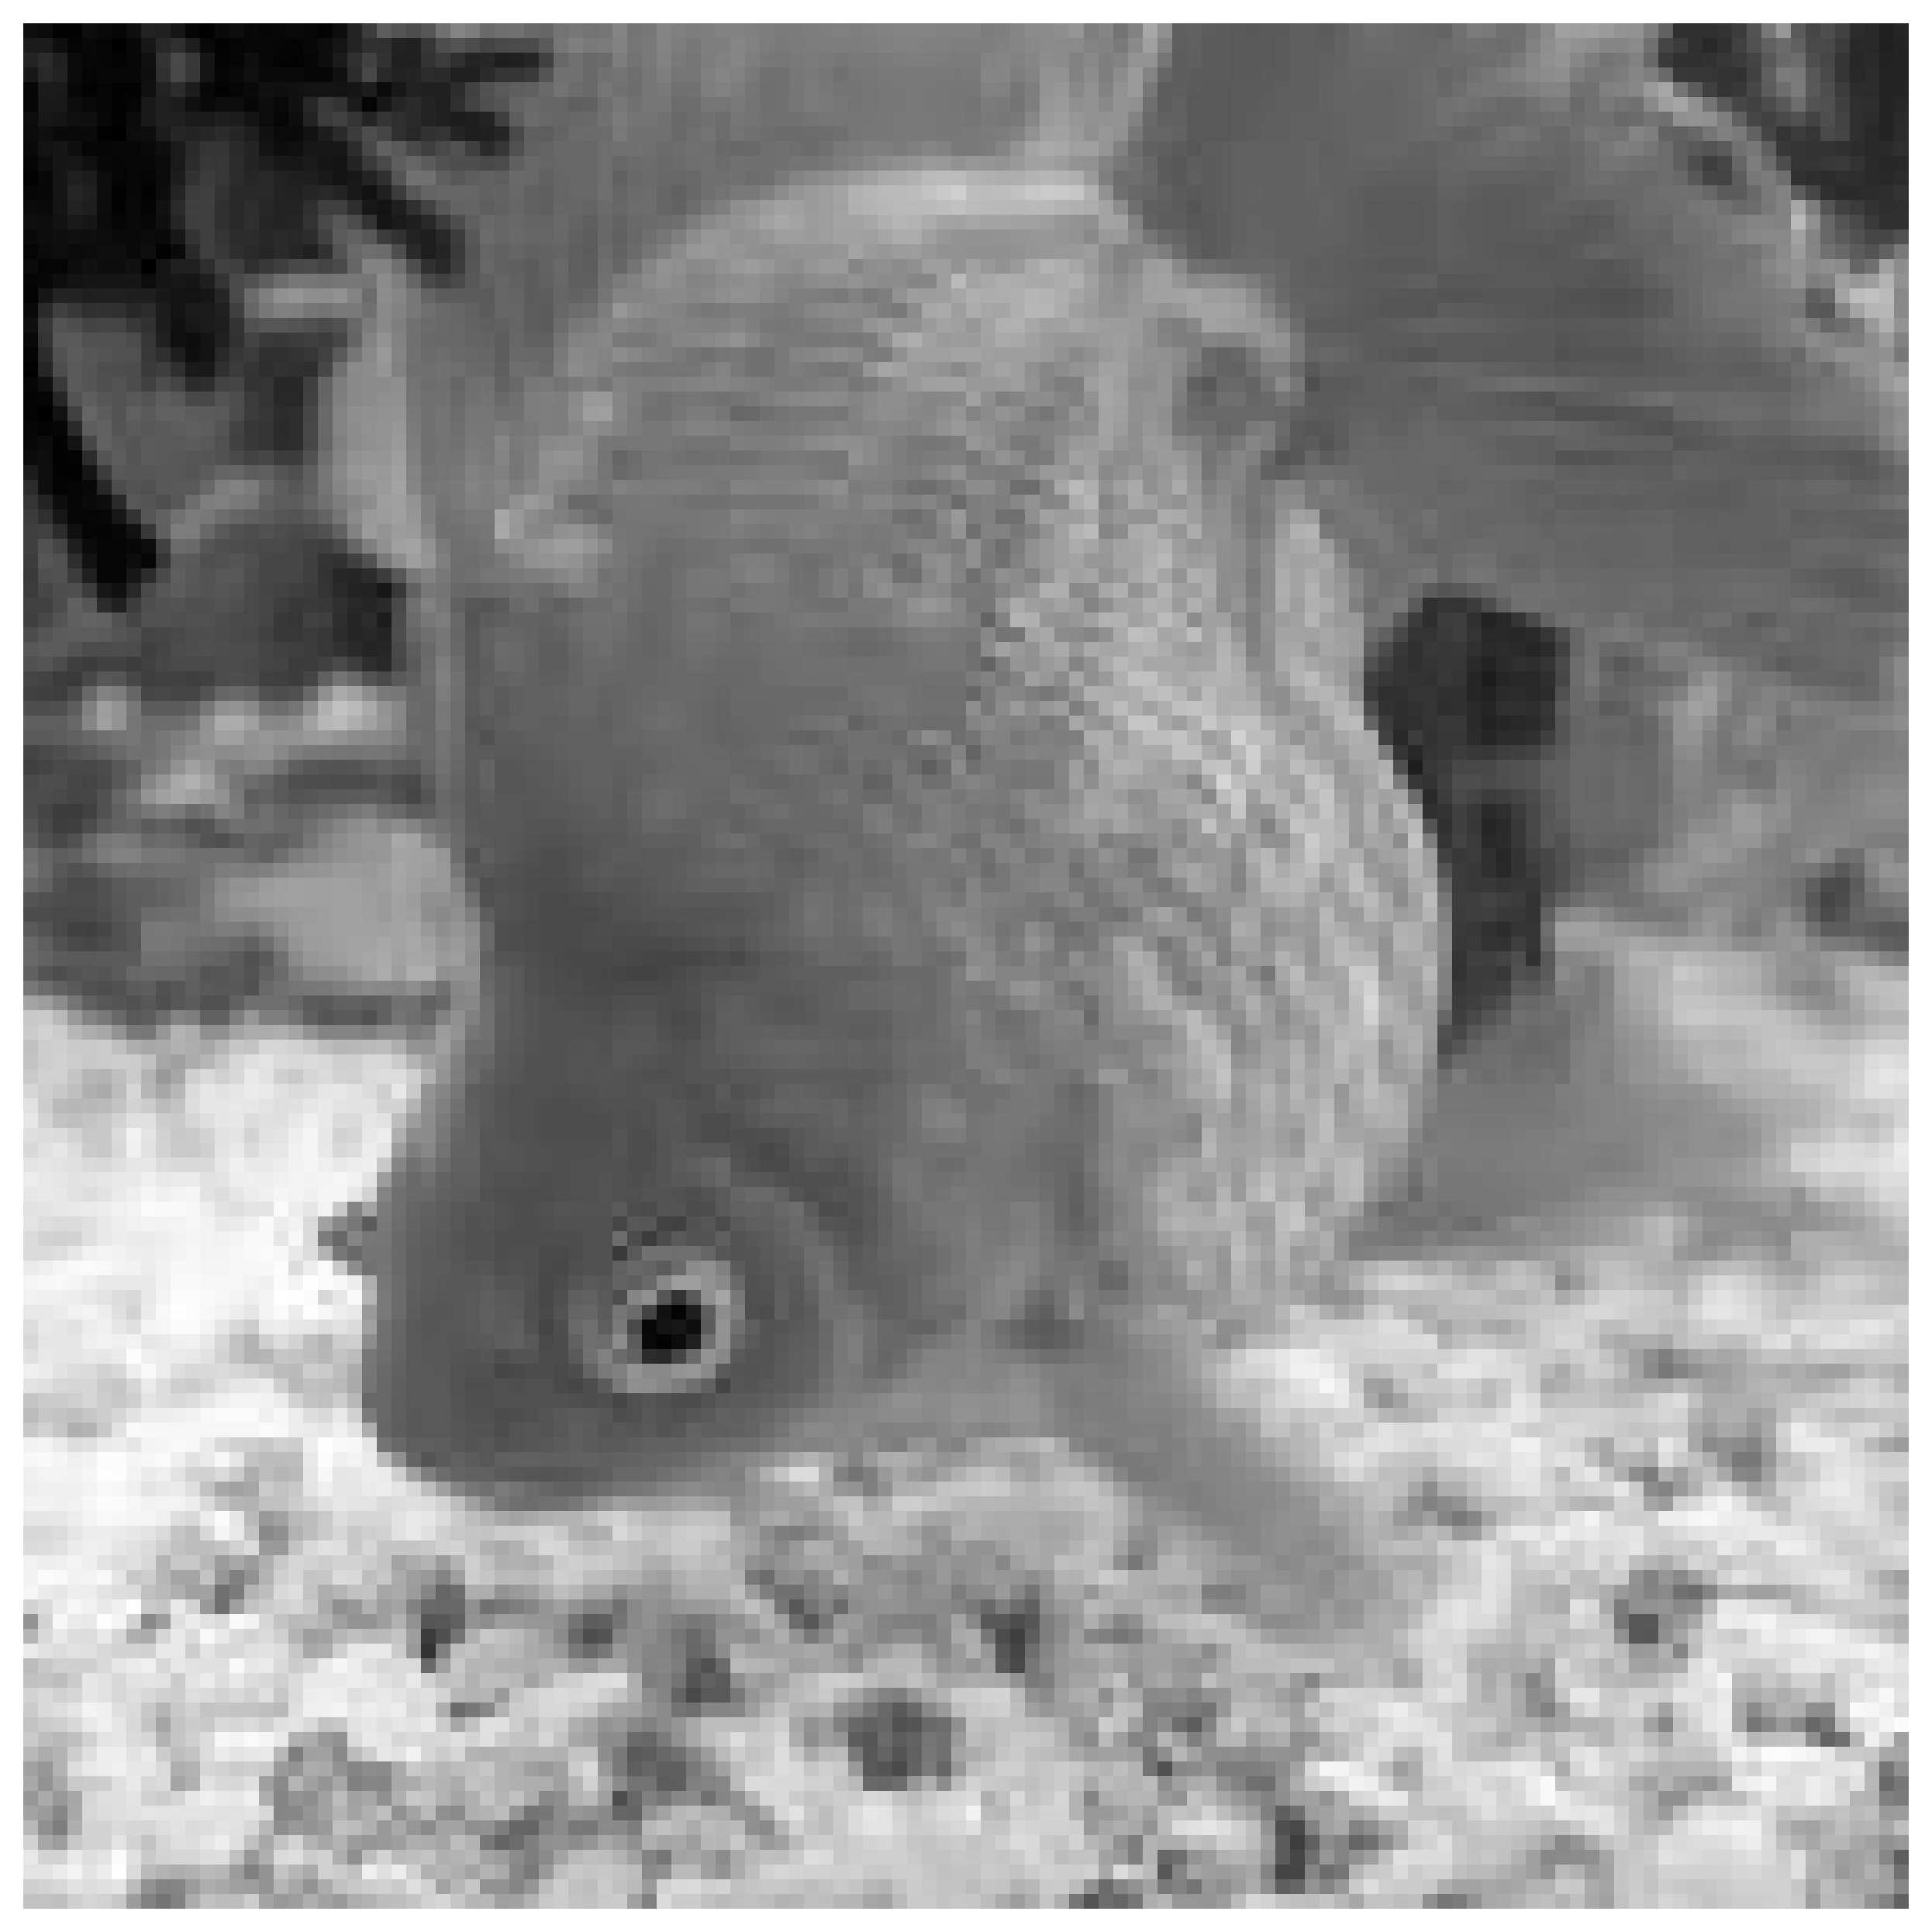

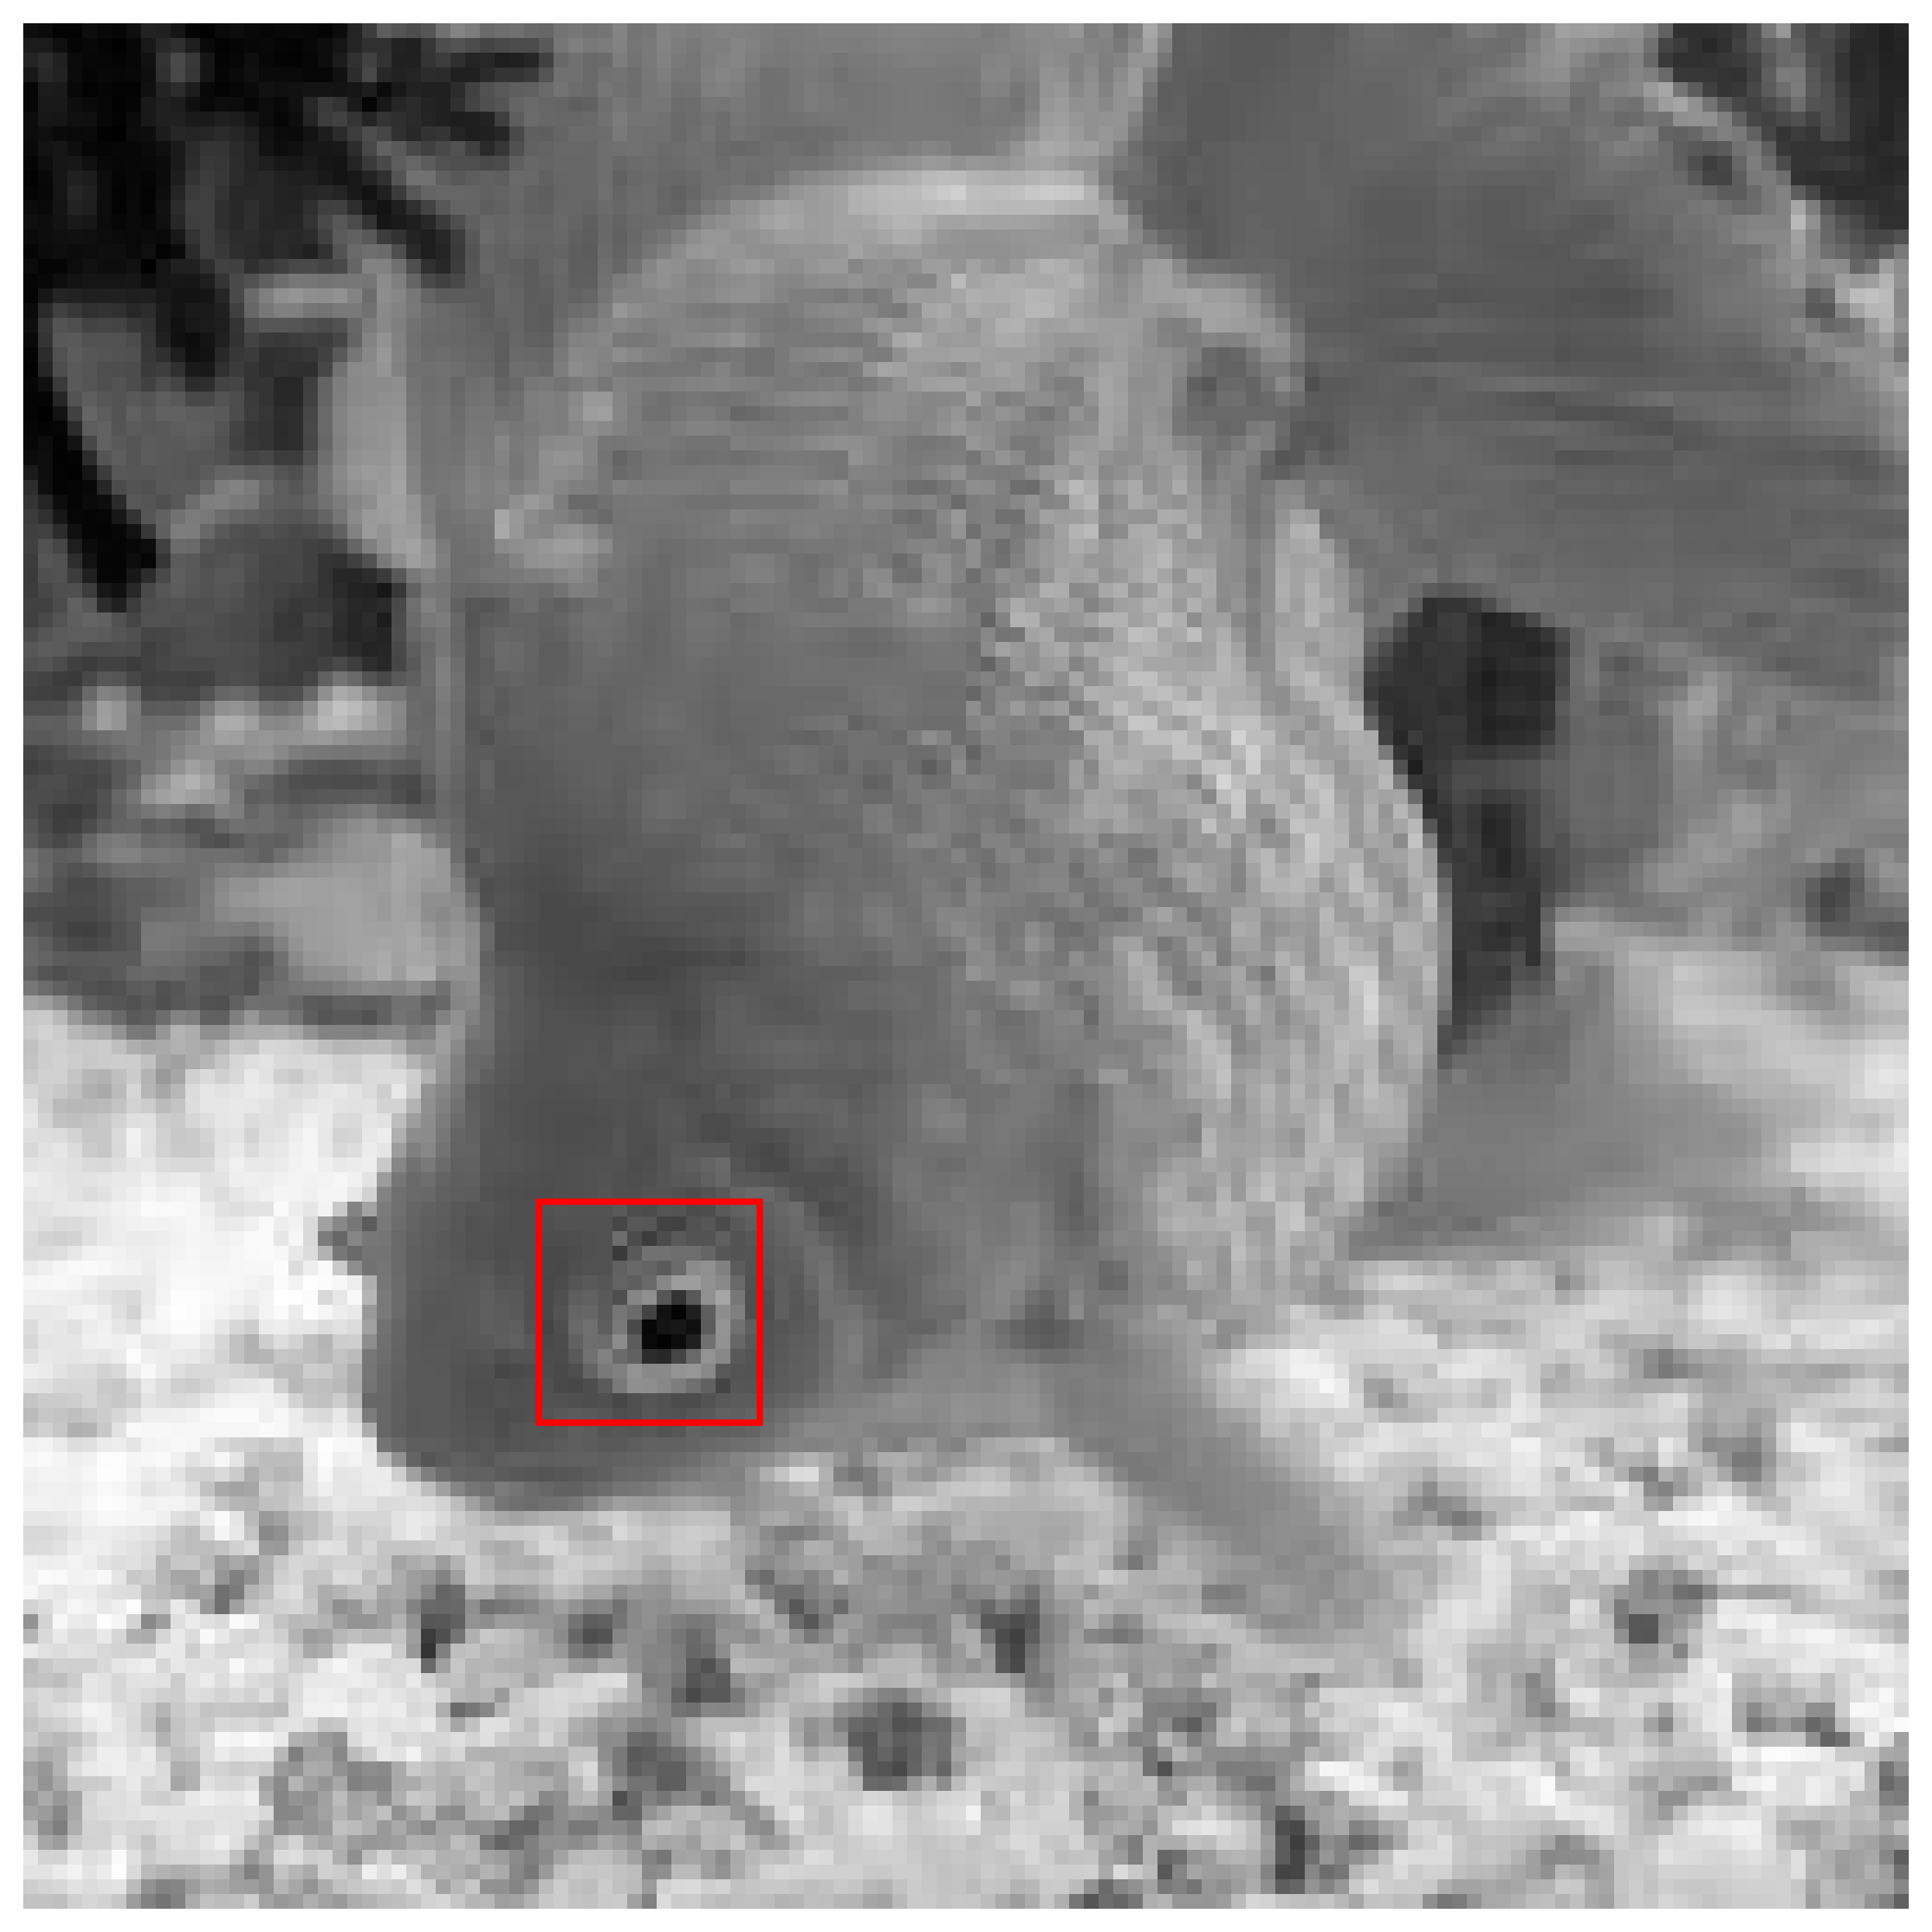

In [4]:
# Load and convert to grayscale
color_img = plt.imread(os.path.join(os.getcwd(), "img.png"))
img = np.dot(color_img[..., :3], [0.2989, 0.5870, 0.1140])

def plt_img(img):
    height, width = img.shape
    dpi = 300
    target_total_pixels = 2400
    pixels_per_cell = max(1, int(round(target_total_pixels / width)))
    exact_inches = (width * pixels_per_cell) / dpi
    fig = plt.figure(figsize=(exact_inches, exact_inches), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1]) 
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt_img(img)
output_path = os.path.join(out_dir, "example_img.png")
plt.savefig(output_path, dpi=300)
plt.show()

plt_img(img)
output_path = os.path.join(out_dir, "example_img_rect.png")
draw_zoom_rectangle(35, 80, 15)
plt.savefig(output_path, dpi=300)
plt.show()

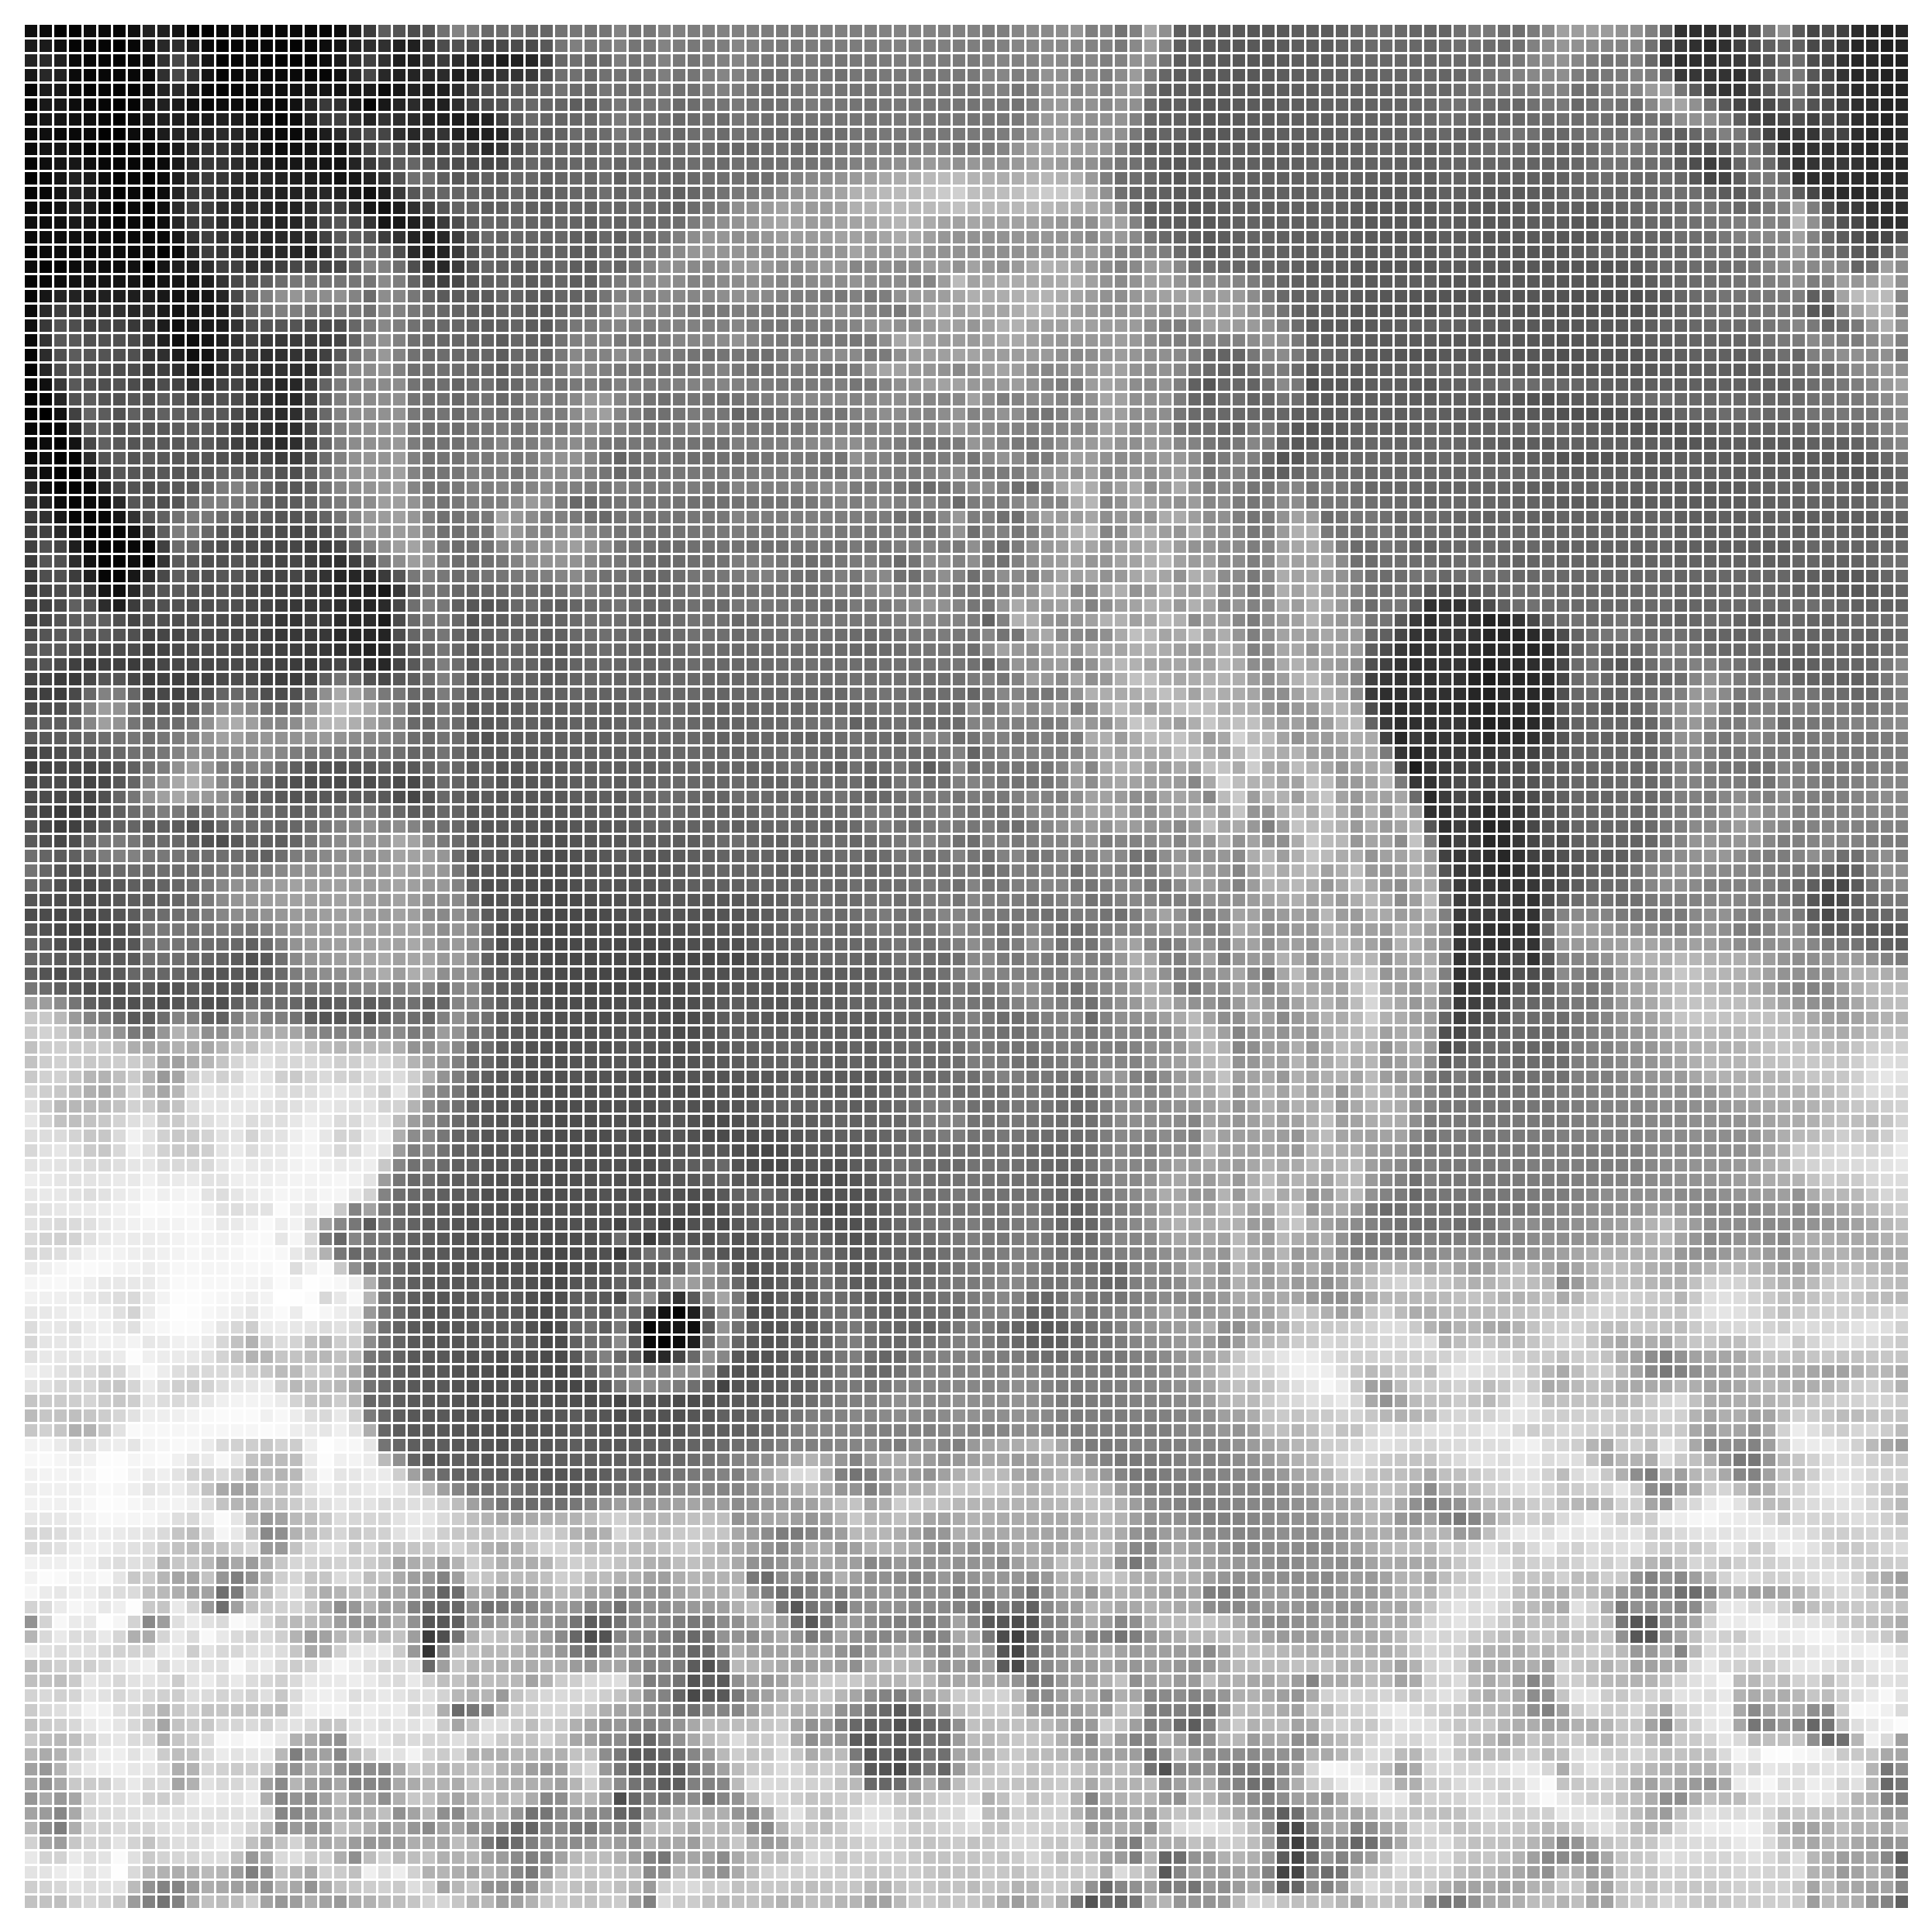

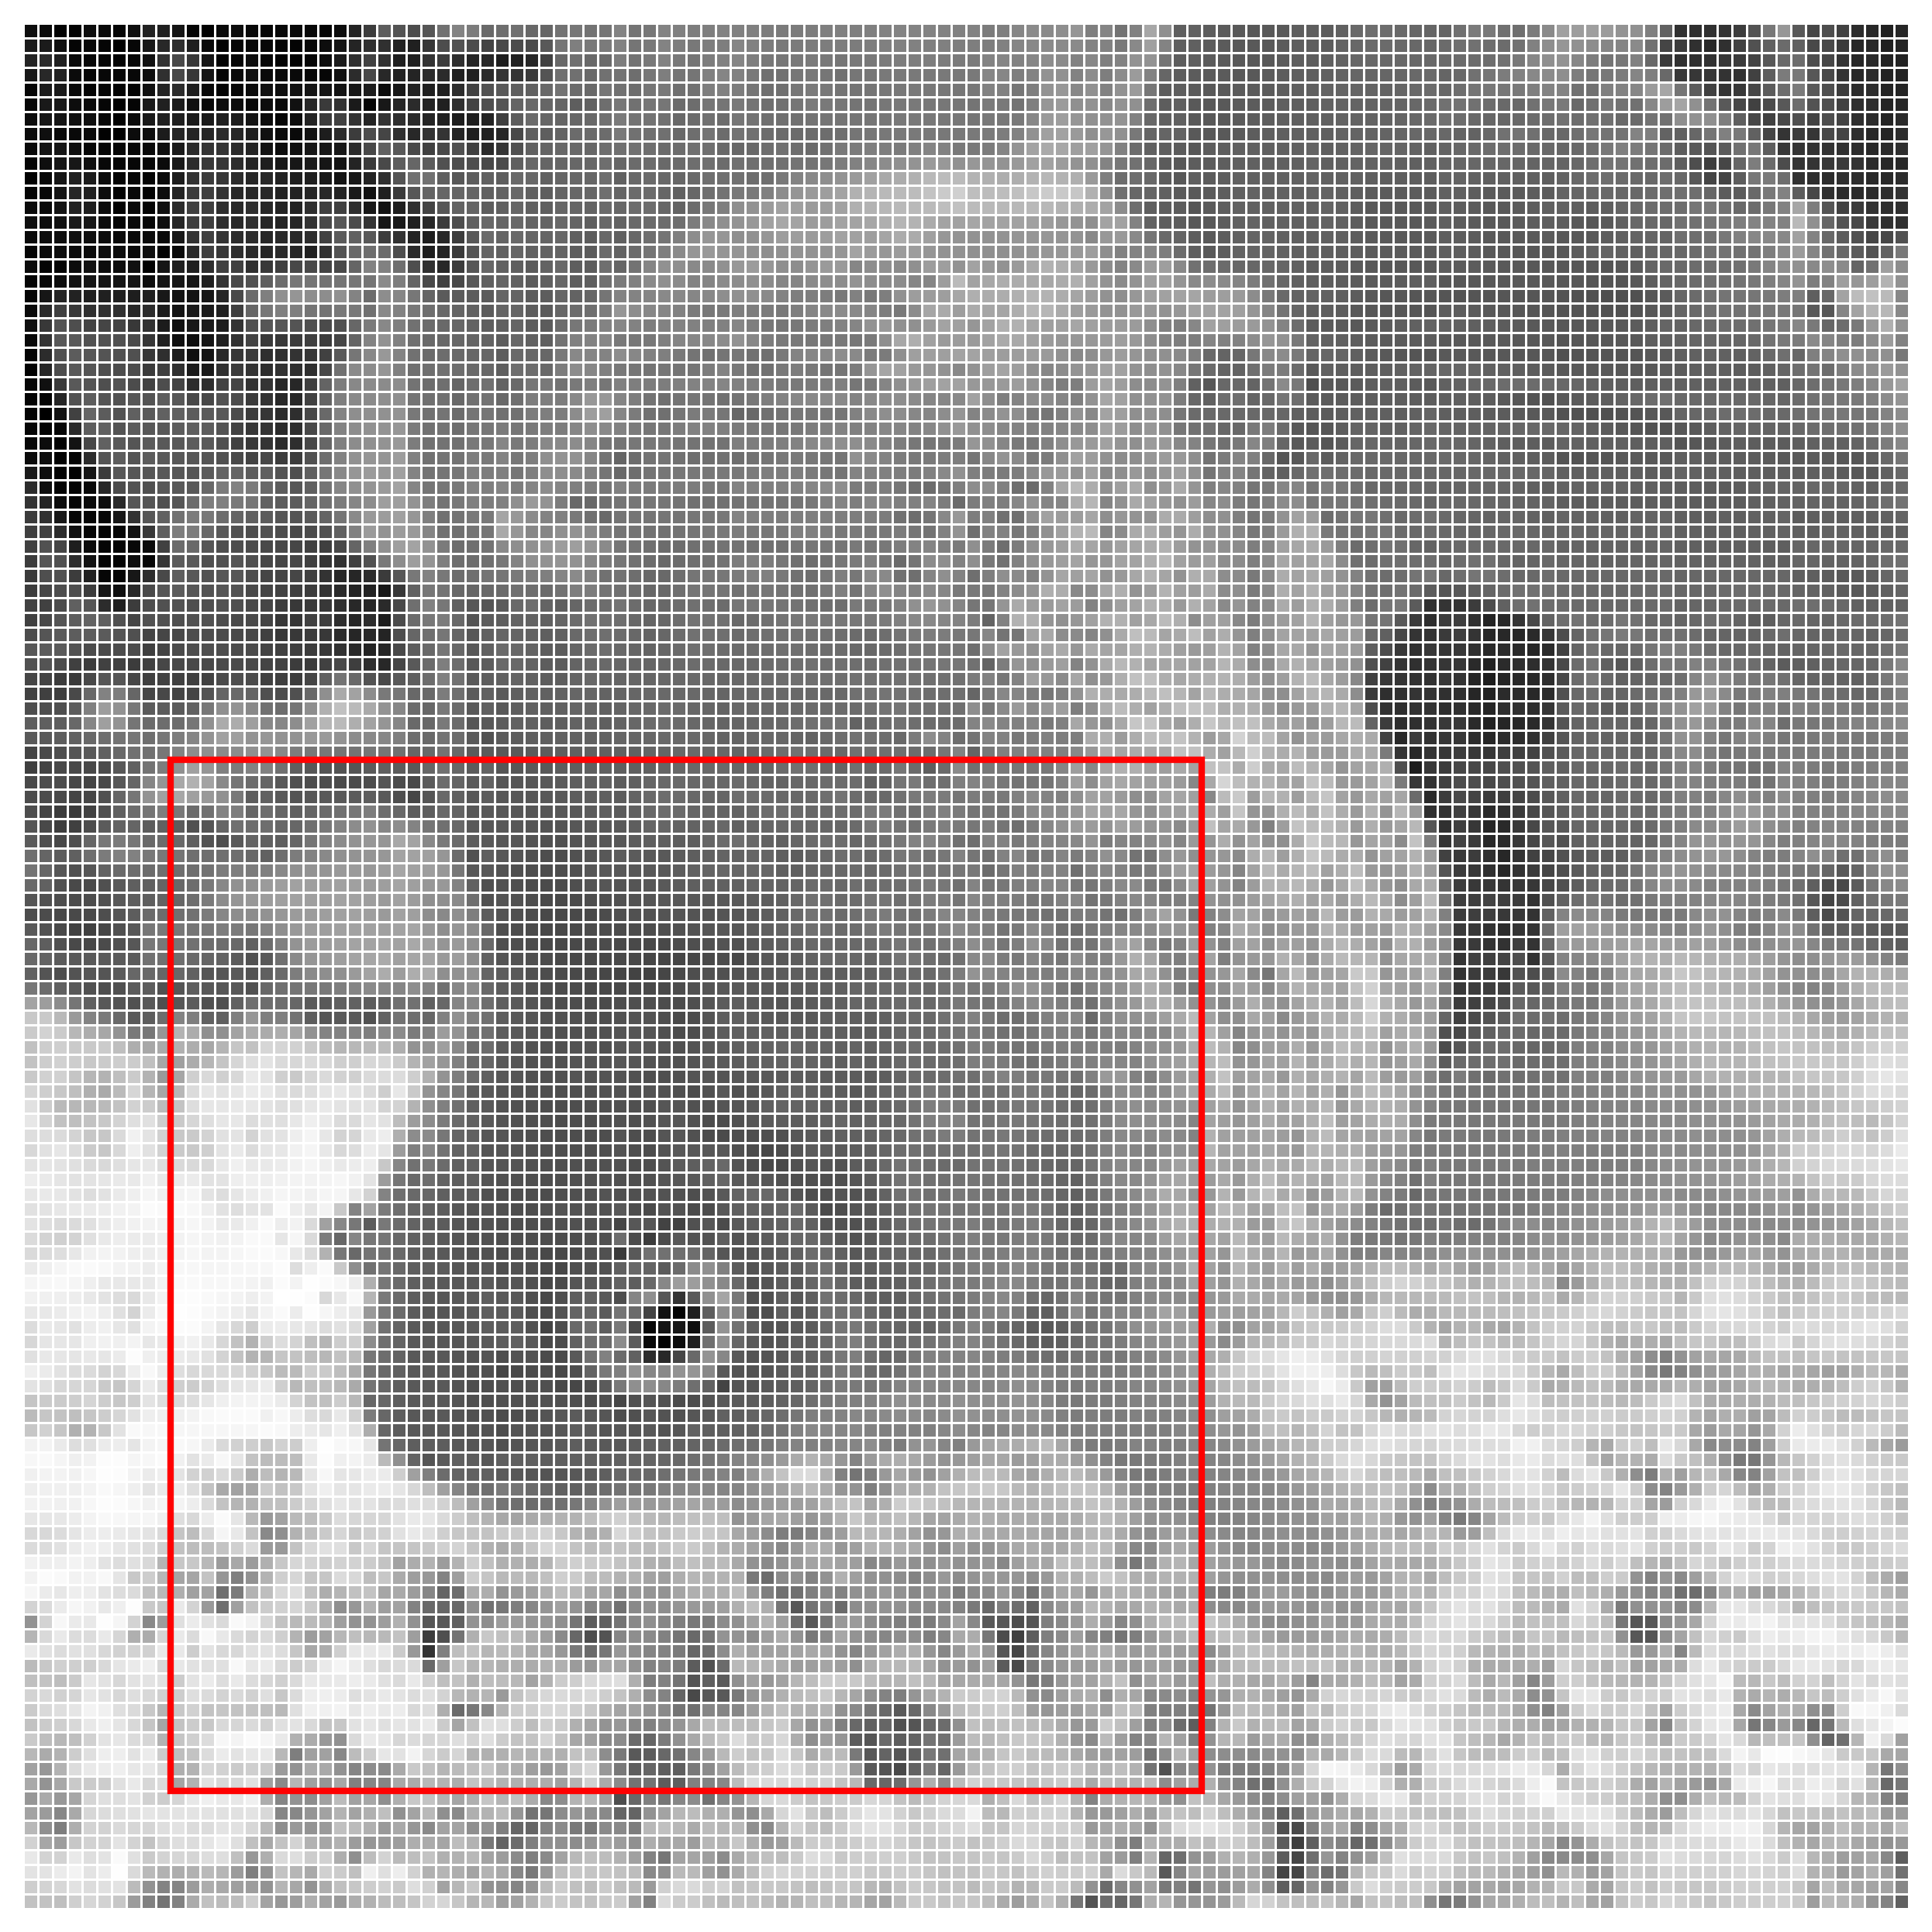

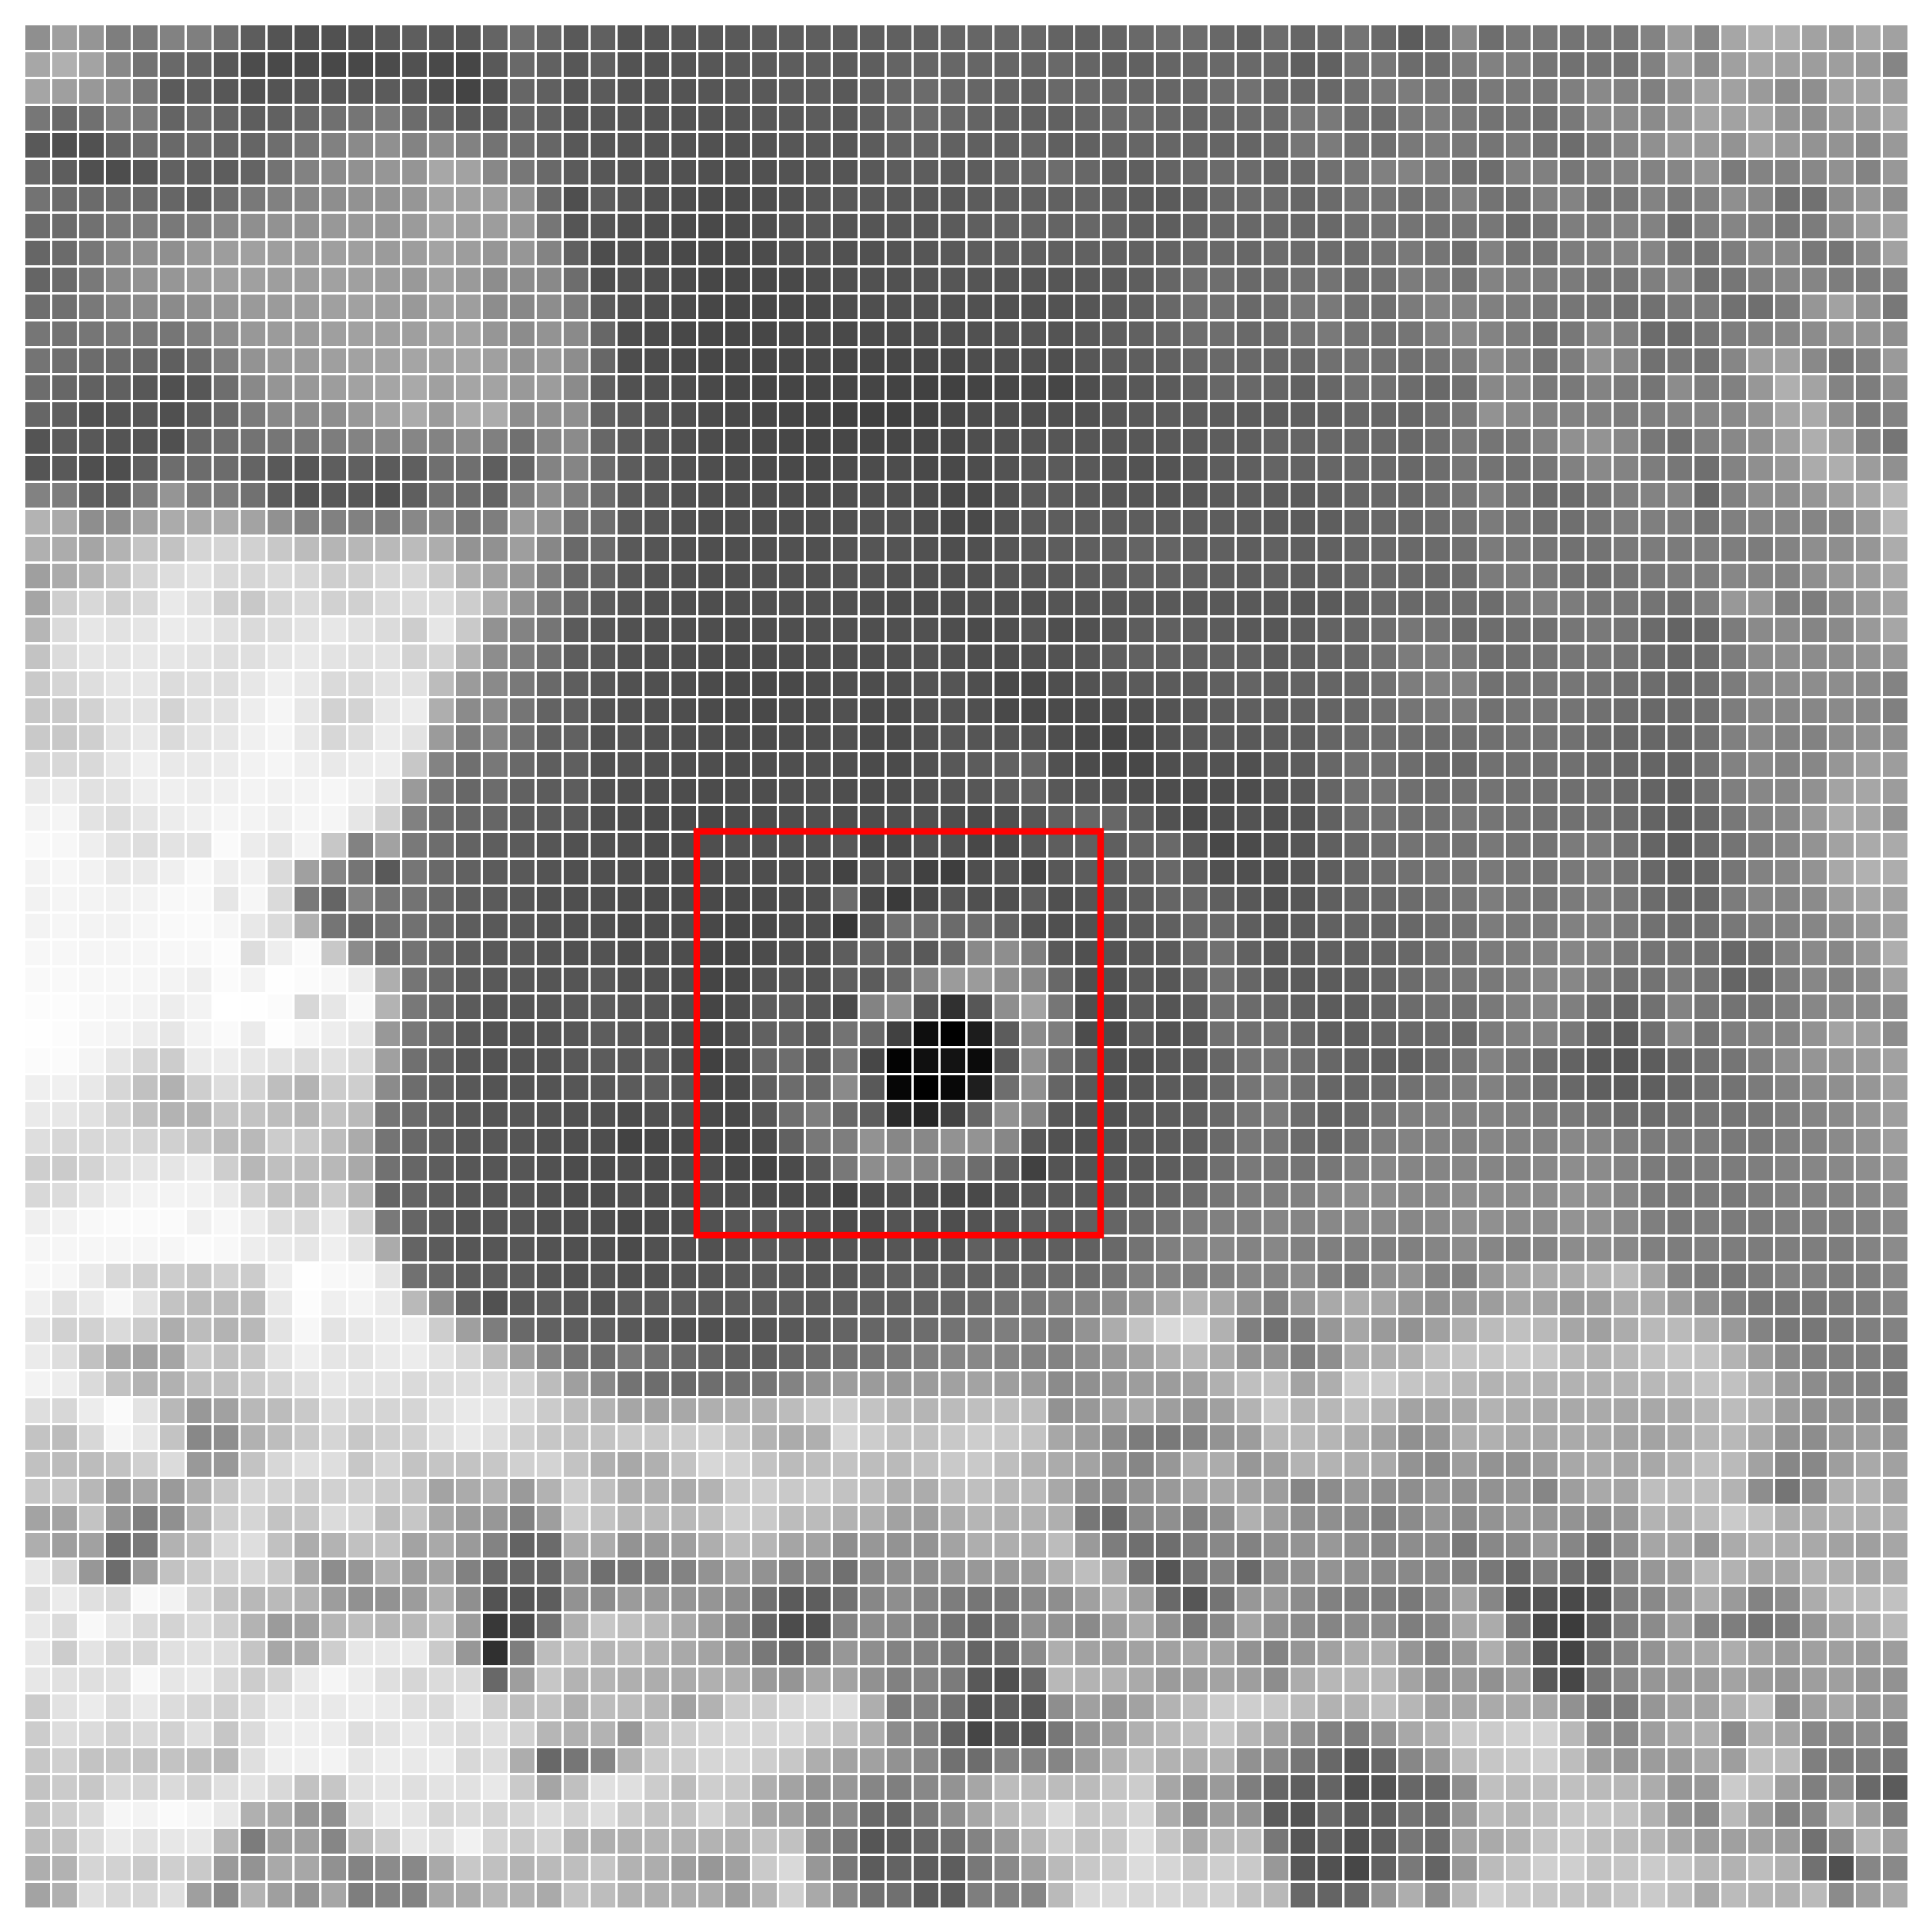

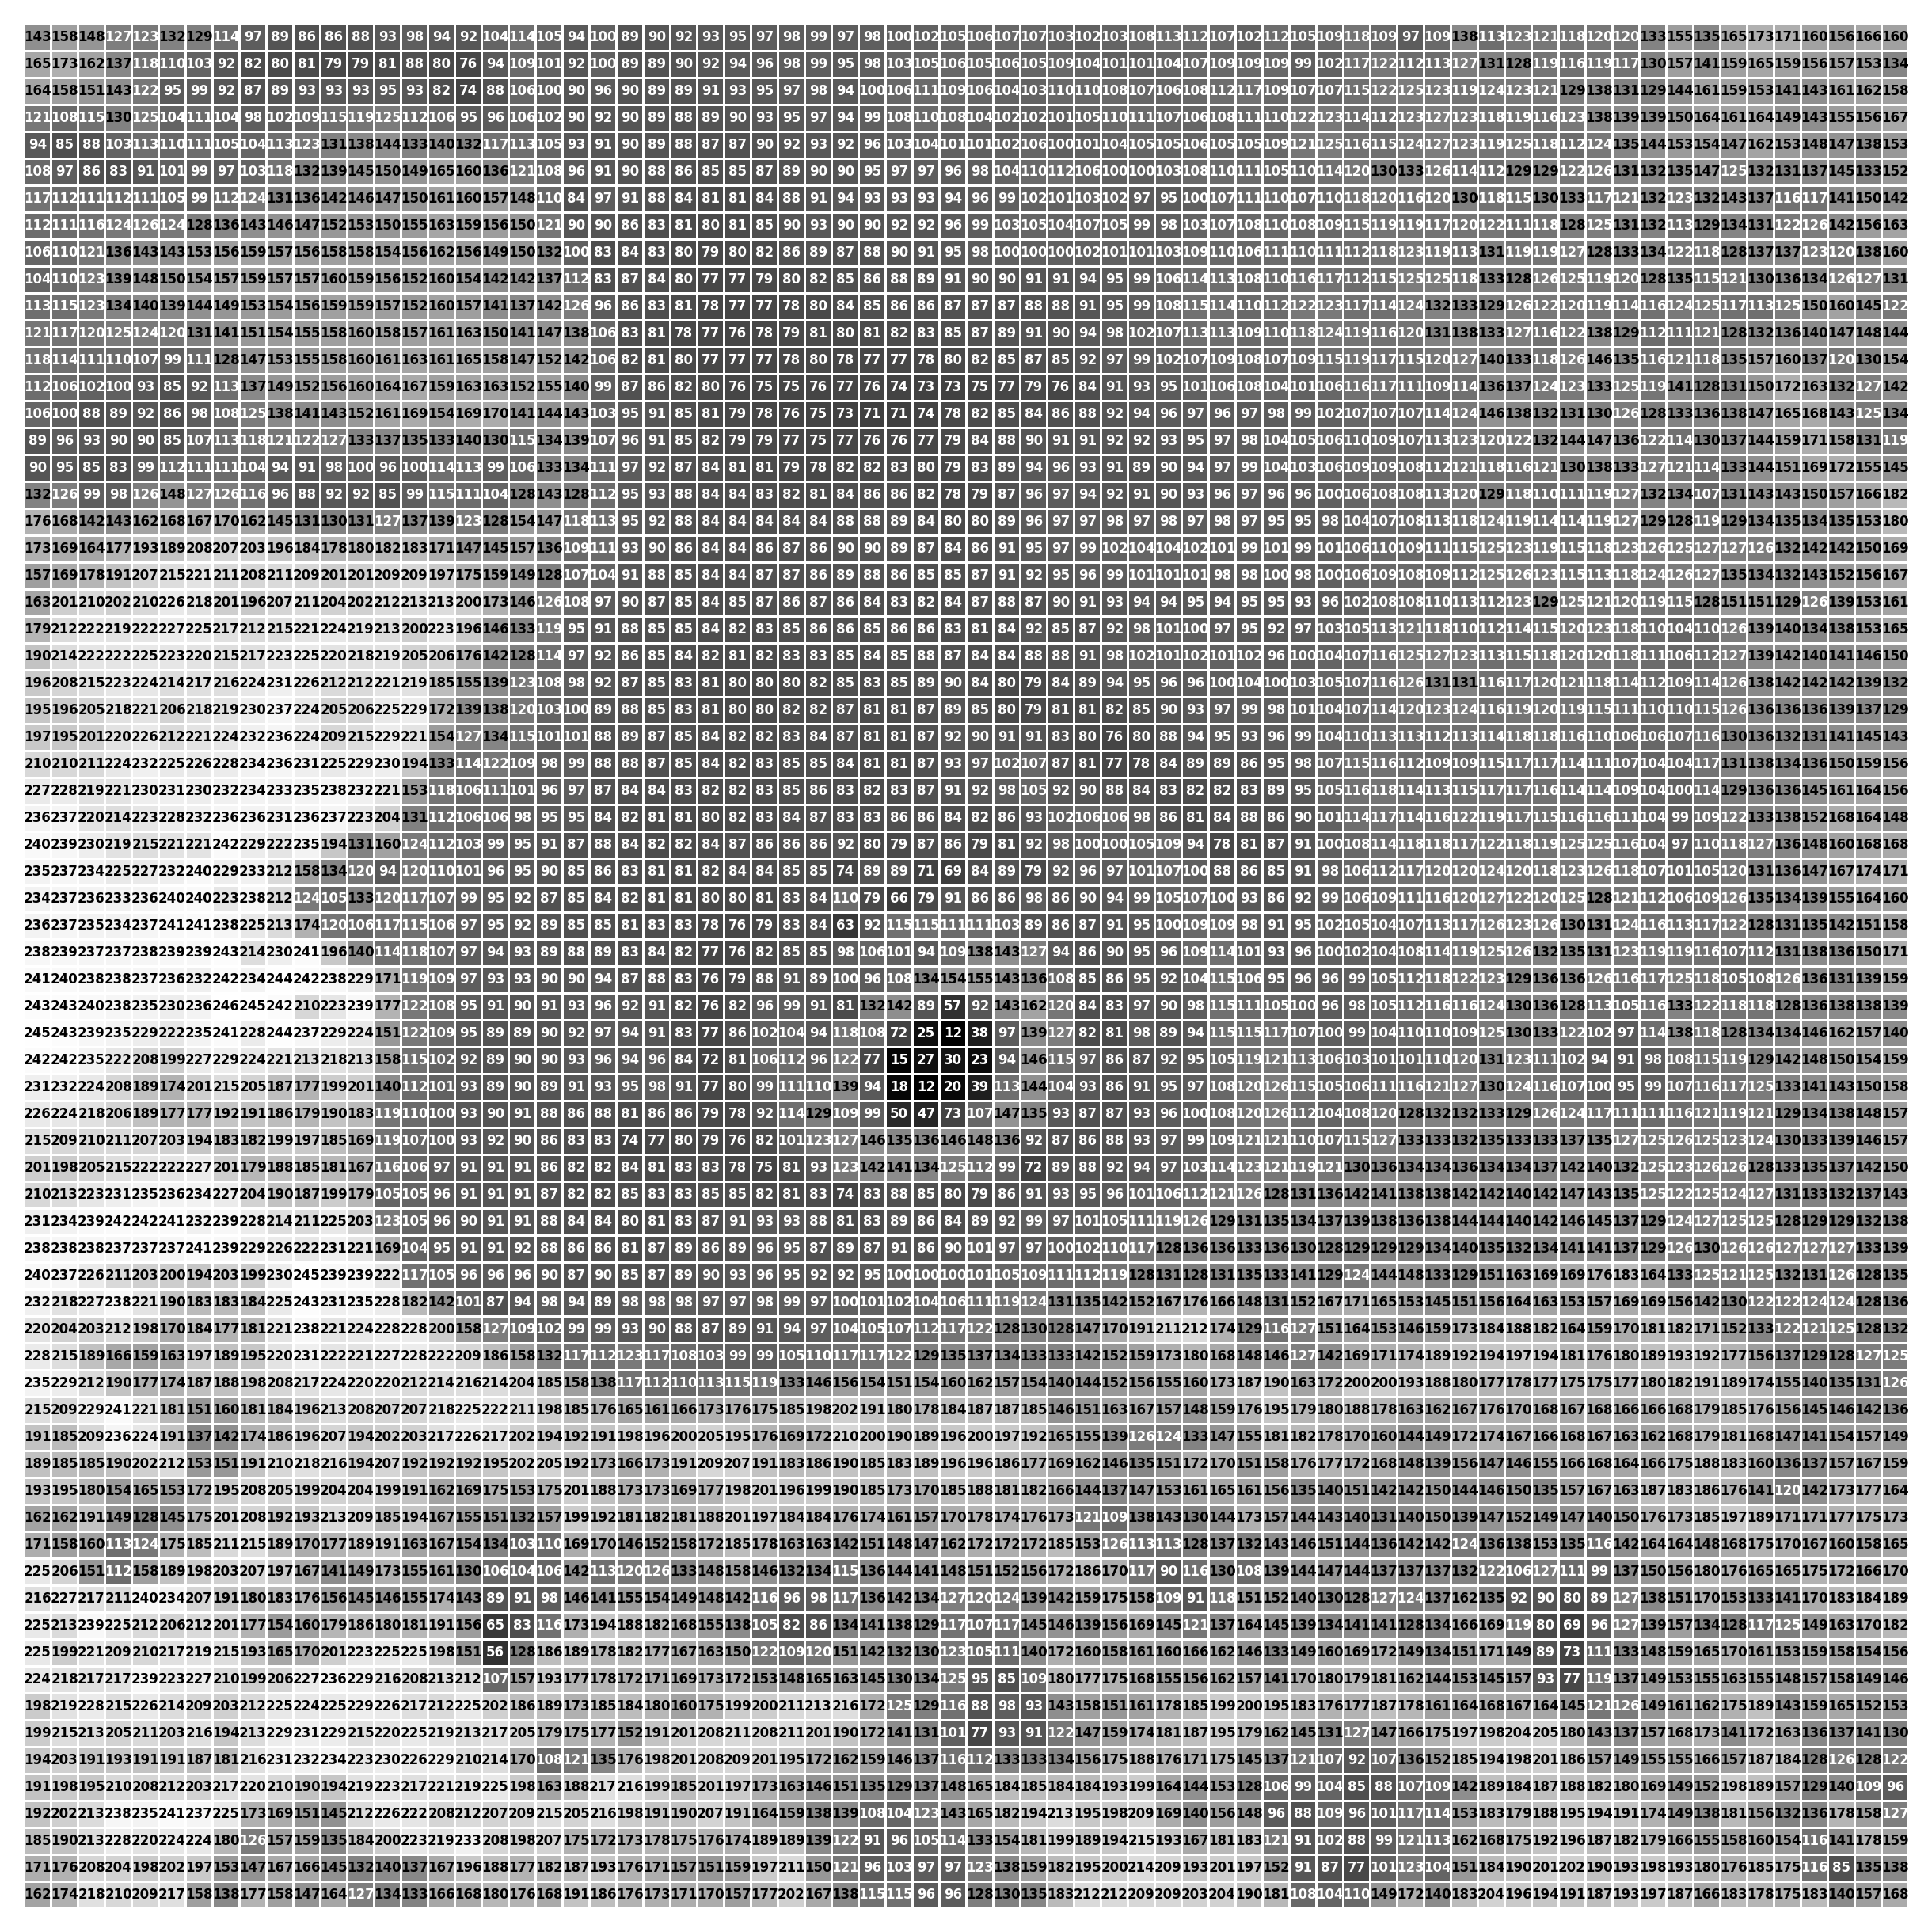

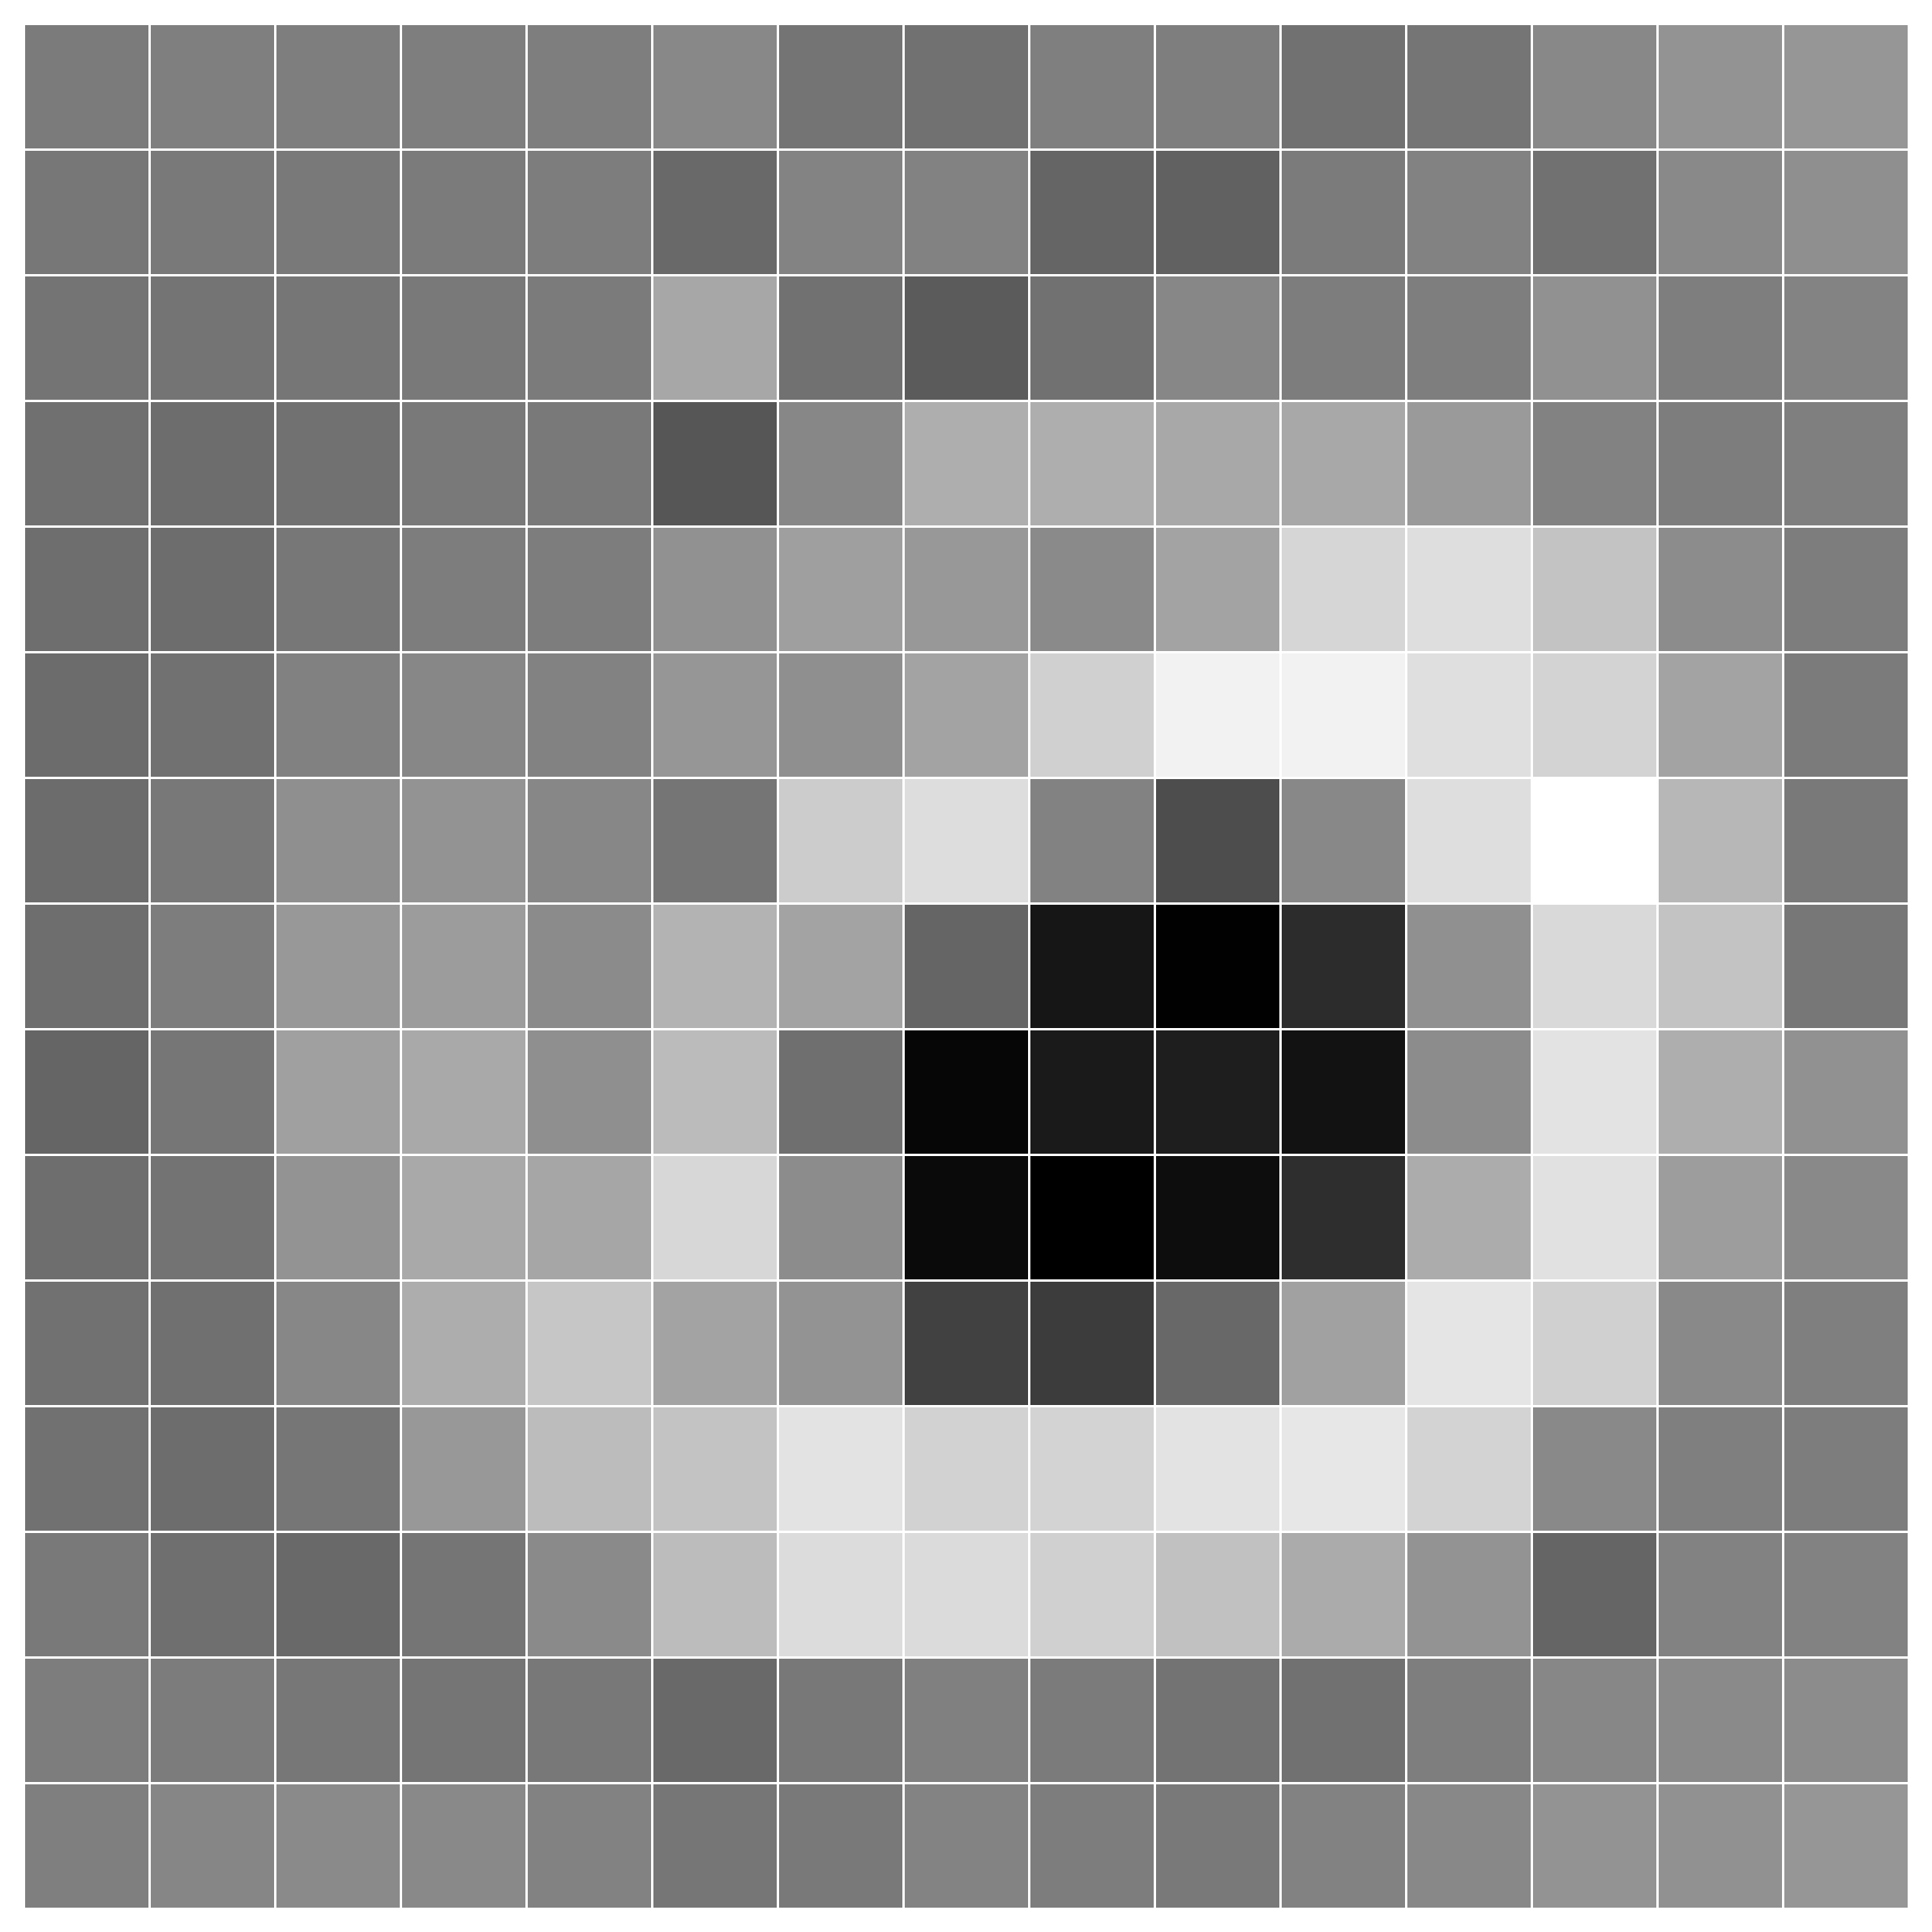

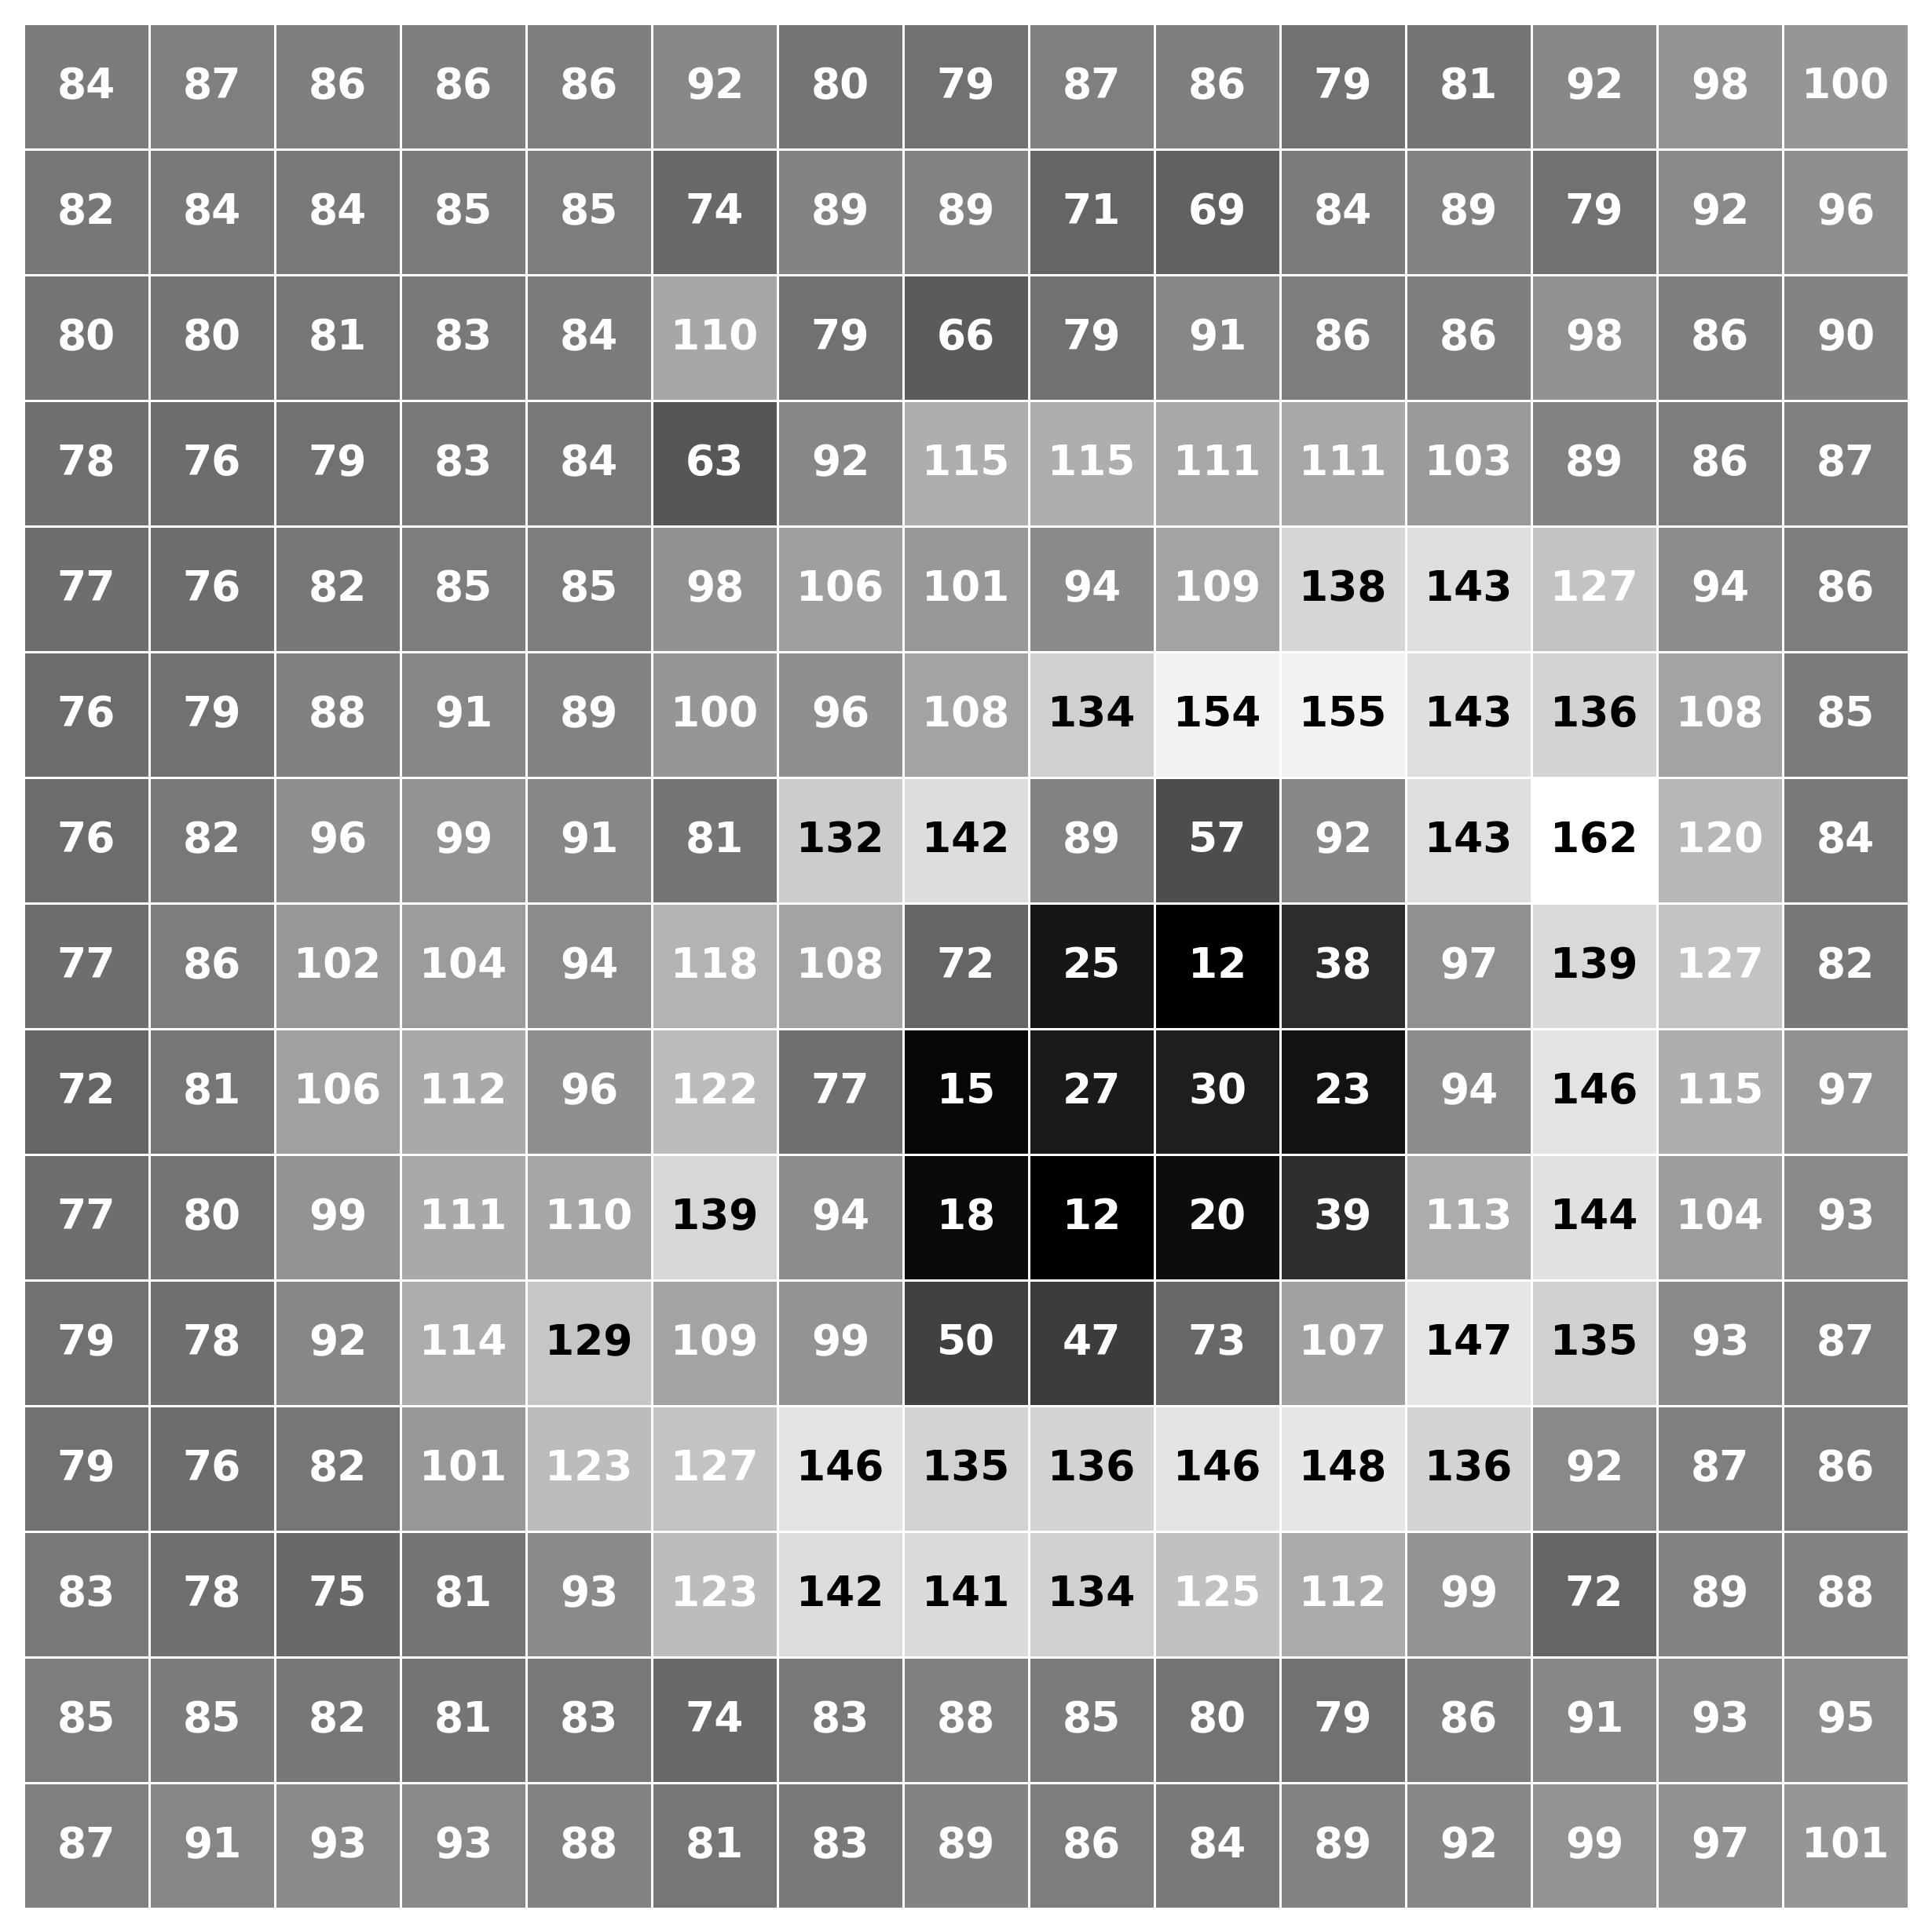

In [5]:
zoomed_img(0, 0, 128)
output_path = os.path.join(out_dir, "pixels_highlighted.png")
plt.savefig(output_path, dpi=300)

zoomed_img(0, 0, 128)
draw_zoom_rectangle(10, 50, 70)
output_path = os.path.join(out_dir, "pixels_highlighted_rect.png")
plt.savefig(output_path, dpi=300)

zoomed_img(10, 50, 70)
draw_zoom_rectangle(35-10, 80-50, 15)
output_path = os.path.join(out_dir, "zoomed_1_pixels_highlighted.png")
plt.savefig(output_path, dpi=300)

zoomed_img(10, 50, 70, show_numbers=True)
# draw_zoom_rectangle(35-10, 80-50, 15)
output_path = os.path.join(out_dir, "zoomed_1_pixels_highlighted_numbers.png")
plt.savefig(output_path, dpi=300)


zoomed_img(35, 80, 15)
output_path = os.path.join(out_dir, "zoomed_2_pixels_highlighted.png")
plt.savefig(output_path, dpi=300)

zoomed_img(35, 80, 15, show_numbers=True)
output_path = os.path.join(out_dir, "zoomed_2_pixels_highlighted_numbers.png")
plt.savefig(output_path, dpi=300)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import os

# --- 1. Extract the exact 15x15 patch and prepare it ---
start_x, start_y, zoom_size = 35, 80, 15
patch = img[start_y : start_y + zoom_size, start_x : start_x + zoom_size]

# Ensure the patch uses 0-255 integer values so the convolution math is clean
if patch.max() <= 1.0:
    patch = (patch * 255).astype(int)
else:
    patch = patch.astype(int)

# --- 2. Define a random 3x3 kernel ---
# Using small integers (-1, 0, 1) keeps the output numbers readable
np.random.seed(42) # For reproducibility
kernel = np.random.randint(-1, 2, size=(3, 3))

print("Kernel used for convolution:")
print(kernel)

# --- 3. Perform the Convolution ---
# 'valid' mode means no padding. 15x15 input with 3x3 kernel -> 13x13 output
feature_map = convolve2d(patch, kernel, mode='valid')

# --- 4. Visualization Function for the Feature Map ---
def plot_feature_map(feat_map, out_dir, filename, show_numbers=True, vmin=None, vmax=None):
    fm_size = feat_map.shape[0]
    
    # Bulletproof pixel math (matching your original setup)
    dpi = 300
    target_total_pixels = 2400
    pixels_per_cell = max(1, int(round(target_total_pixels / fm_size)))
    exact_inches = (fm_size * pixels_per_cell) / dpi
    
    fig = plt.figure(figsize=(exact_inches, exact_inches), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1]) 
    
        
    # Use 'viridis' to visually separate the hidden layer from the grayscale input
    ax.imshow(feat_map, interpolation='nearest', cmap='gray', vmin=vmin, vmax=vmax)
    
    exact_lw_points = 3 * (72 / dpi)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=exact_lw_points)
    
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    
    if show_numbers:
        for i in range(fm_size):      
            for j in range(fm_size):  
                val = feat_map[i, j]
                # Dynamic text color: black for mid-tones in viridis, white for dark/light extremes
                text_color = 'white'
                
                dynamic_fontsize = max(4, pixels_per_cell * 0.08)
                
                ax.text(j, i, str(int(val)), 
                        ha='center', va='center', 
                        color=text_color, 
                        fontsize=dynamic_fontsize, fontweight='bold')
                
    output_path = os.path.join(out_dir, filename)
    plt.savefig(output_path, dpi=300)
    plt.close(fig)

# --- 5. Generate and Save ---
plot_feature_map(
    feature_map, 
    out_dir, 
    "zoomed_3_feature_map_numbers.png", 
    show_numbers=True
)

Kernel used for convolution:
[[ 1 -1  1]
 [ 1 -1 -1]
 [ 1  0  1]]


In [7]:
# --- 6. Max Pooling (2x2 kernel, stride 2) WITHOUT cropping ---
# Calculate how much padding is needed to make the dimensions even
pad_h = feature_map.shape[0] % 2
pad_w = feature_map.shape[1] % 2

# Pad the right and bottom edges with the smallest possible integer 
# for the given dtype so the padded zeros don't accidentally become the max
padded_fm = np.pad(
    feature_map, 
    pad_width=((0, pad_h), (0, pad_w)), 
    mode='constant', 
    constant_values=np.iinfo(feature_map.dtype).min
)

# Calculate new output dimensions (14 / 2 = 7)
h_out = padded_fm.shape[0] // 2
w_out = padded_fm.shape[1] // 2

# Reshape into blocks of 2x2, then take the maximum across the block axes
feature_map_pooled = padded_fm.reshape(h_out, 2, w_out, 2).max(axis=(1, 3))

print("Pooled feature map shape:", feature_map_pooled.shape, feature_map.min(), feature_map.max())

# --- 7. Generate and Save Pooled Feature Map ---
plot_feature_map(
    feature_map_pooled, 
    out_dir, 
    "zoomed_4_pooled_feature_map_numbers.png", 
    show_numbers=True,
    vmin=feature_map.min(),
    vmax=feature_map.max()
)

Pooled feature map shape: (7, 7) -18 362


In [9]:
import os
import io
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Assuming zoomed_img and draw_zoom_rectangle are already defined in your script
# out_dir = "your_output_directory"

def create_stride_gif(stride, kernel_size, grid_width, grid_height, out_dir, filename):
    """
    Loops over an image grid with a specific stride and saves the animation as a GIF.
    Fades out pixels that are dropped due to 'valid' padding.
    """
    frames = []
    
    max_x = grid_width - kernel_size + 1
    max_y = grid_height - kernel_size + 1
    
    # 1. Calculate all the valid starting positions
    valid_xs = list(range(0, max_x, stride))
    valid_ys = list(range(0, max_y, stride))
    
    # Catch edge cases where the kernel is larger than the grid
    if not valid_xs or not valid_ys:
        print(f"Skipping {filename}: Kernel is too large to fit in the grid.")
        return
        
    # 2. Calculate exactly how many pixels are covered by the final step
    covered_w = valid_xs[-1] + kernel_size
    covered_h = valid_ys[-1] + kernel_size
    
    print(f"Generating {filename}... (Grid: {grid_width}x{grid_height} | Covered: {covered_w}x{covered_h})")
    
    for y in valid_ys:
        for x in valid_xs:
            plt.clf() 
            
            # 3. Draw your base image
            zoomed_img(35, 80, 15, show_numbers=True)
            
            ax = plt.gca()
            
            # 5. Draw the sliding rectangle on top
            draw_zoom_rectangle(x, y, kernel_size)
            
            # 6. Save the plot to an in-memory buffer
            buf = io.BytesIO()
            # bbox_inches='tight' helps prevent matplotlib from cutting off edges
            plt.savefig(buf, format='png', dpi=150, bbox_inches='tight') 
            buf.seek(0)
            
            frames.append(Image.open(buf))
            plt.close('all')
            
    # 7. Save the frames as a looping GIF
    if frames:
        output_path = os.path.join(out_dir, filename)
        frames[0].save(
            output_path,
            save_all=True,
            append_images=frames[1:],
            duration=400,  
            loop=0         
        )
        print(f"Successfully saved {output_path}\n")

# --- Generation ---

GRID_W = 15
GRID_H = 15

# Example loops
for kernel_size in [3, 5, 7]:
    for stride in [1, 2, 3]:
        create_stride_gif(
            stride=stride, 
            kernel_size=kernel_size, 
            grid_width=GRID_W, 
            grid_height=GRID_H, 
            out_dir=out_dir, 
            filename=f"stride_{stride}_kernel_{kernel_size}.gif"
        )

Generating stride_1_kernel_3.gif... (Grid: 15x15 | Covered: 15x15)
Successfully saved /Users/mebr/Documents/FHNW/CAS Data Science/FS26/cas_machine-learning-slides/code-examples/plots/cnn/../../out/cnn/stride_1_kernel_3.gif

Generating stride_2_kernel_3.gif... (Grid: 15x15 | Covered: 15x15)
Successfully saved /Users/mebr/Documents/FHNW/CAS Data Science/FS26/cas_machine-learning-slides/code-examples/plots/cnn/../../out/cnn/stride_2_kernel_3.gif

Generating stride_3_kernel_3.gif... (Grid: 15x15 | Covered: 15x15)
Successfully saved /Users/mebr/Documents/FHNW/CAS Data Science/FS26/cas_machine-learning-slides/code-examples/plots/cnn/../../out/cnn/stride_3_kernel_3.gif

Generating stride_1_kernel_5.gif... (Grid: 15x15 | Covered: 15x15)
Successfully saved /Users/mebr/Documents/FHNW/CAS Data Science/FS26/cas_machine-learning-slides/code-examples/plots/cnn/../../out/cnn/stride_1_kernel_5.gif

Generating stride_2_kernel_5.gif... (Grid: 15x15 | Covered: 15x15)
Successfully saved /Users/mebr/Docume

In [16]:
import os
import io
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

def create_stride_gif(stride, kernel_size, grid_width, grid_height, padding_type, out_dir, filename, start_x=35, start_y=80):
    frames = []
    
    # 1. Padding berechnen
    if padding_type.lower() == 'same':
        pad_val = (kernel_size - 1) // 2
    else:
        pad_val = 0

    effective_w = grid_width + 2 * pad_val
    effective_h = grid_height + 2 * pad_val
    
    # Start- und Endpunkte für den Kernel berechnen
    max_x = effective_w - kernel_size + 1
    max_y = effective_h - kernel_size + 1
    
    valid_xs = list(range(0, max_x, stride))
    valid_ys = list(range(0, max_y, stride))
    
    if not valid_xs or not valid_ys:
        print(f"Skipping {filename}: Kernel passt nicht.")
        return

    print(f"Generating {filename} ({padding_type})... (Grid: {effective_w}x{effective_h})")
    
    # 2. Das Bild-Array laden und ECHTES Numpy-Padding anwenden!
    # (Wir gehen davon aus, dass 'img' global verfügbar ist, wie in deiner Funktion)
    base_patch = img[start_y : start_y + grid_height, start_x : start_x + grid_width]
    
    if pad_val > 0:
        padded_patch = np.pad(base_patch, pad_width=pad_val, mode='constant', constant_values=0)
    else:
        padded_patch = base_patch

    # --- BULLETPROOF PIXEL MATH (angepasst an effektive Größe) ---
    dpi = 300
    target_total_pixels = 2400
    # Nutze die maximale Breite/Höhe für die Skalierung
    pixels_per_cell = max(1, int(round(target_total_pixels / max(effective_w, effective_h))))
    
    exact_inches_w = (effective_w * pixels_per_cell) / dpi
    exact_inches_h = (effective_h * pixels_per_cell) / dpi
    # -------------------------------------------------------------

    for y in valid_ys:
        for x in valid_xs:
            plt.clf()
            
            # Figure mit exakten Abmessungen erstellen
            fig = plt.figure(figsize=(exact_inches_w, exact_inches_h), dpi=dpi)
            ax = fig.add_axes([0, 0, 1, 1]) 
            
            # Das gepaddete Array anzeigen
            ax.imshow(padded_patch, interpolation='nearest', cmap='gray')
            
            # Achsen strikt locken
            ax.set_xlim(-0.5, effective_w - 0.5)
            ax.set_ylim(effective_h - 0.5, -0.5) 
            
            ax.set_xticks(np.arange(-0.5, effective_w, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, effective_h, 1), minor=True)
            
            exact_lw_points = 3 * (72 / dpi)
            ax.grid(which='minor', color='white', linestyle='-', linewidth=exact_lw_points)
            
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
            
            # Zahlen einfügen
            for i in range(effective_h):      
                for j in range(effective_w):  
                    val = padded_patch[i, j]
                    val_255 = int(val * 255) if img.max() <= 1.0 else int(val)
                    
                    # Logik: Ist dieser Pixel ein Padding-Pixel?
                    is_pad = (i < pad_val or i >= pad_val + grid_height or 
                              j < pad_val or j >= pad_val + grid_width)
                    
                    text_color = 'black' if val_255 > 127 else 'white'
                    
                    # Optisches Feedback: Padding-Nullen hellgrau machen
                    if is_pad:
                        text_color = '#aaaaaa' 
                    
                    dynamic_fontsize = max(4, pixels_per_cell * 0.08)
                    
                    ax.text(j, i, str(val_255), 
                            ha='center', va='center', 
                            color=text_color, 
                            fontsize=dynamic_fontsize, fontweight='bold')
            
            # --- 3. Den Sliding Kernel zeichnen ---
            # Da das Array direkt vergrößert wurde, können wir x und y nativ nutzen
            rect = patches.Rectangle((x - 0.5, y - 0.5), kernel_size, kernel_size, 
                                     linewidth=3, edgecolor='red', facecolor='none', zorder=10)
            ax.add_patch(rect)
            
            # 4. Speichern
            buf = io.BytesIO()
            plt.savefig(buf, format='png', dpi=dpi, bbox_inches='tight', pad_inches=0)
            buf.seek(0)
            frames.append(Image.open(buf))
            plt.close('all') # fig schließen, um Memory Leaks zu vermeiden
            
    # GIF speichern
    if frames:
        output_path = os.path.join(out_dir, filename)
        frames[0].save(
            output_path,
            save_all=True,
            append_images=frames[1:],
            duration=400,
            loop=0
        )
        print(f"Successfully saved {output_path}\n")

# --- Example loops ---
GRID_W = 15
GRID_H = 15

for p_type in ['valid', 'same']:
    for kernel_size in [3, 5, 7]: 
        for stride in [1, 2, 3]:
            create_stride_gif(
                stride=stride, 
                kernel_size=kernel_size, 
                grid_width=GRID_W, 
                grid_height=GRID_H, 
                padding_type=p_type,
                out_dir=out_dir, 
                filename=f"conv_{p_type}_s{stride}_k{kernel_size}.gif"
            )

Generating conv_valid_s1_k3.gif (valid)... (Grid: 15x15)
Successfully saved /Users/mebr/Documents/FHNW/CAS Data Science/FS26/cas_machine-learning-slides/code-examples/plots/cnn/../../out/cnn/conv_valid_s1_k3.gif

Generating conv_valid_s2_k3.gif (valid)... (Grid: 15x15)
Successfully saved /Users/mebr/Documents/FHNW/CAS Data Science/FS26/cas_machine-learning-slides/code-examples/plots/cnn/../../out/cnn/conv_valid_s2_k3.gif

Generating conv_valid_s3_k3.gif (valid)... (Grid: 15x15)
Successfully saved /Users/mebr/Documents/FHNW/CAS Data Science/FS26/cas_machine-learning-slides/code-examples/plots/cnn/../../out/cnn/conv_valid_s3_k3.gif

Generating conv_valid_s1_k5.gif (valid)... (Grid: 15x15)
Successfully saved /Users/mebr/Documents/FHNW/CAS Data Science/FS26/cas_machine-learning-slides/code-examples/plots/cnn/../../out/cnn/conv_valid_s1_k5.gif

Generating conv_valid_s2_k5.gif (valid)... (Grid: 15x15)
Successfully saved /Users/mebr/Documents/FHNW/CAS Data Science/FS26/cas_machine-learning-sl